In [418]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [419]:
df=pd.read_csv("week3_csv.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [420]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [421]:
df.head()
df["holiday"].value_counts()

holiday
Labor Day                    7
Thanksgiving Day             6
Christmas Day                6
New Years Day                6
Martin Luther King Jr Day    6
Columbus Day                 5
Veterans Day                 5
Washingtons Birthday         5
Memorial Day                 5
Independence Day             5
State Fair                   5
Name: count, dtype: int64

In [422]:
df["holiday"]=df["holiday"].fillna("None")

In [423]:
df["holiday"].value_counts()

holiday
None                         48143
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Independence Day                 5
State Fair                       5
Name: count, dtype: int64

In [424]:
from sklearn.preprocessing import LabelEncoder

In [425]:
objcols=["holiday","weather_main","weather_description"]
enc=LabelEncoder()
for col in objcols:
    df[col] = enc.fit_transform(df[col])


In [426]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,7,288.28,0.0,0.0,40,1,24,2012-10-02 09:00:00,5545
1,7,289.36,0.0,0.0,75,1,2,2012-10-02 10:00:00,4516
2,7,289.58,0.0,0.0,90,1,19,2012-10-02 11:00:00,4767
3,7,290.13,0.0,0.0,90,1,19,2012-10-02 12:00:00,5026
4,7,291.14,0.0,0.0,75,1,2,2012-10-02 13:00:00,4918


In [427]:
df["date_time"] = pd.to_datetime(df["date_time"])
df["hour"] = df["date_time"].dt.hour
df["day"] = df["date_time"].dt.day
df["month"] = df["date_time"].dt.month
df["day_of_week"] = df["date_time"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["day"] = df["date_time"].dt.day
df["week"] = df["date_time"].dt.isocalendar().week


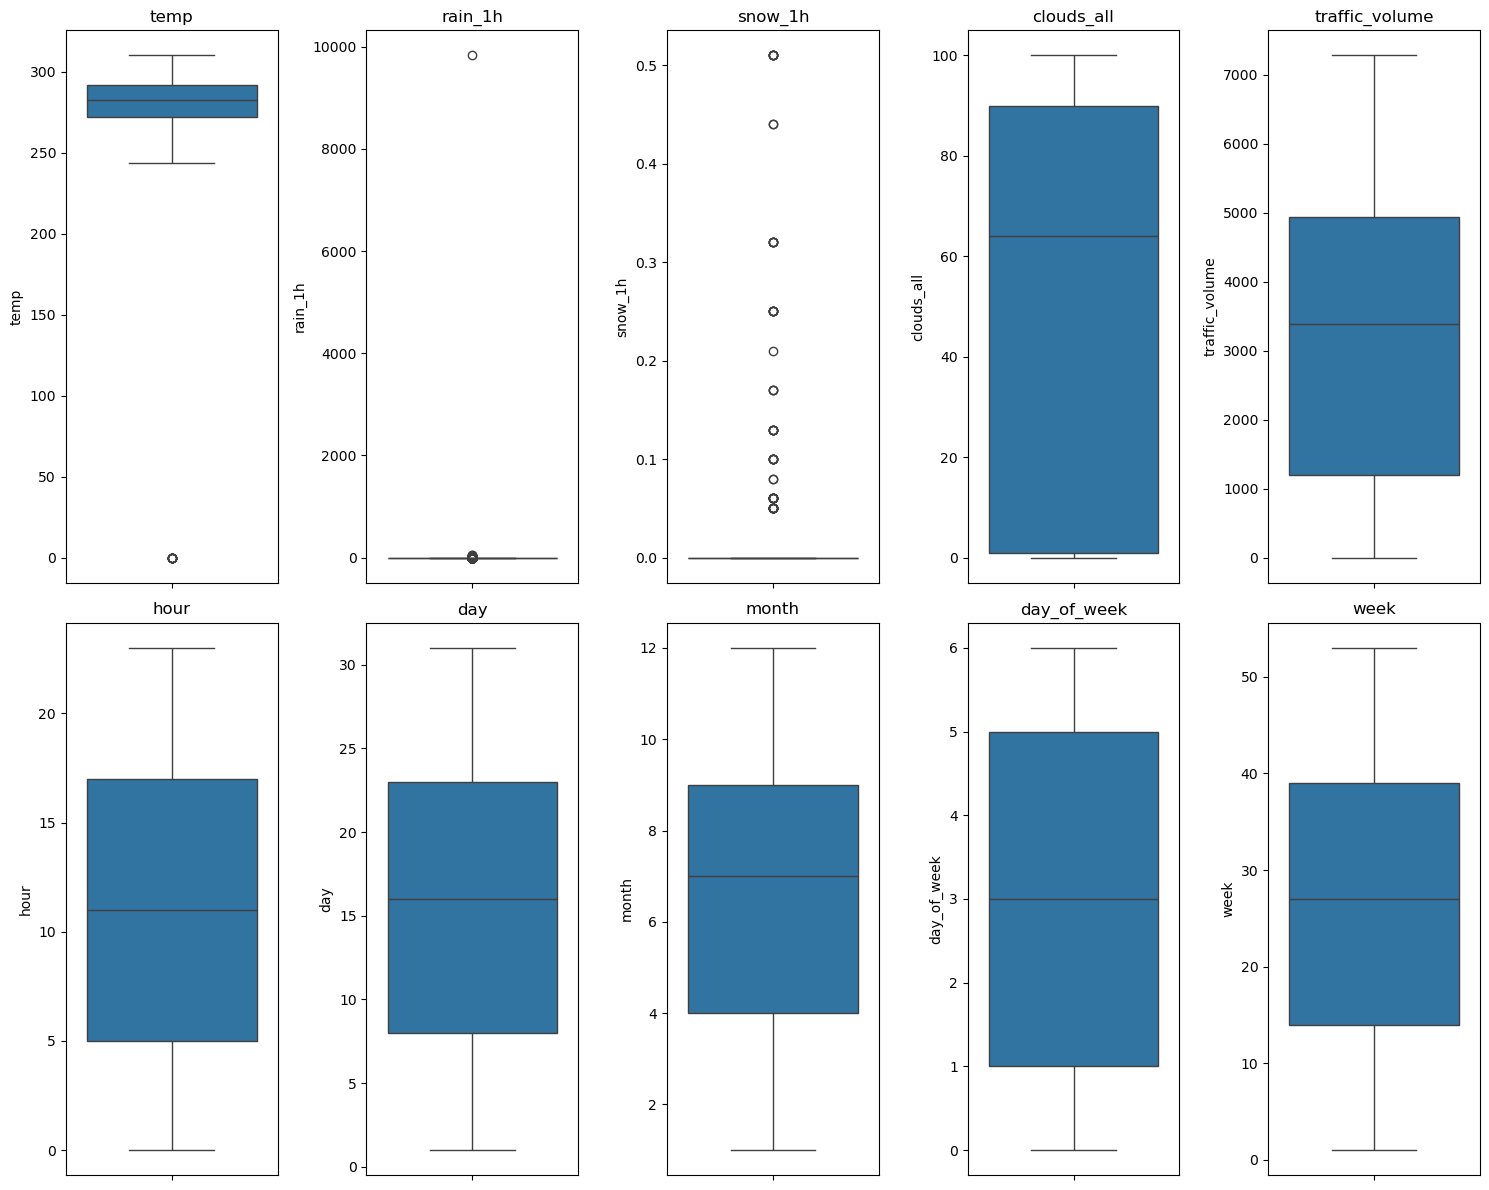

In [428]:
numcol=df[['temp','rain_1h','snow_1h','clouds_all','traffic_volume', 'hour','day','month','day_of_week','week']]
plt.figure(figsize=(15,12))
for i, col in enumerate(numcol, 1):
    plt.subplot(2, 5, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [429]:
for col in ['rain_1h', 'snow_1h']:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper =q3+1.5*iqr
    df=df[(df[col]>=lower)&(df[col]<=upper)]

In [430]:
X=df.drop(columns=["traffic_volume","date_time"],axis=1)
y=df["traffic_volume"]

In [431]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2 ,random_state=42)

In [432]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [433]:
y_pred_rf = rf.predict(X_test)

In [434]:
from sklearn.ensemble import AdaBoostRegressor
ada= AdaBoostRegressor(random_state=42)
ada.fit(X_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,loss,'linear'
,random_state,42


In [435]:
y_pred_ada = ada.predict(X_test)

In [436]:
from xgboost import XGBRegressor

In [437]:
xgb=XGBRegressor(random_state=42)
xgb.fit(X_train,y_train)
y_pred_xgb=xgb.predict(X_test)

In [438]:
from sklearn.metrics import r2_score
print("R 2 SCORES")
print("by random forest:",r2_score(y_test,y_pred_rf))
print("by adaboost:",r2_score(y_test,y_pred_ada))
print("by xgboost:",r2_score(y_test,y_pred_xgb))

R 2 SCORES
by random forest: 0.9630367521702256
by adaboost: 0.819958325138104
by xgboost: 0.9700971841812134


In [439]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
print("mean absolute errors")
print()
print("by random forest:", mean_absolute_error(y_test,y_pred_rf))
print()
print("by ADABOOST:", mean_absolute_error(y_test,y_pred_ada))
print()
print("by XGBOOST:", mean_absolute_error(y_test,y_pred_xgb))
print()
print("root mean squared errors")
print()
print("by random forest:", root_mean_squared_error(y_test,y_pred_rf))
print()
print("by adaboost:", root_mean_squared_error(y_test,y_pred_ada))
print()
print("by xgboost:", root_mean_squared_error(y_test,y_pred_xgb))

mean absolute errors

by random forest: 224.43406741725445

by ADABOOST: 629.7001294318243

by XGBOOST: 216.5452423095703

root mean squared errors

by random forest: 382.5728516632899

by adaboost: 844.3365862739564

by xgboost: 344.1004333496094
